In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import uuid
import matplotlib.pyplot as plt

In [117]:
from pathlib import Path

data_dir = Path("data")

file_list = []
for f in data_dir.glob("*.csv"):
	file_list.append(f)

In [118]:
n_participants = len(file_list)
n_participants

8

In [119]:
df = pd.read_csv("data/1234543_stroop_2026-05-10_23h09.56.735 2.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   instruct.started   1 non-null      float64
 1   instruct.stopped   1 non-null      float64
 2   participant        42 non-null     int64  
 3   session            42 non-null     int64  
 4   date               42 non-null     str    
 5   expName            42 non-null     str    
 6   psychopyVersion    42 non-null     str    
 7   OS                 42 non-null     str    
 8   frameRate          42 non-null     float64
 9   trial.started      40 non-null     str    
 10  trial.stopped      40 non-null     str    
 11  resp.keys          40 non-null     str    
 12  resp.corr          40 non-null     float64
 13  resp.rt            40 non-null     float64
 14  resp.duration      0 non-null      float64
 15  trials.thisRepN    40 non-null     float64
 16  trials.thisTrialN  40 non-null     floa

In [120]:
df.head(3)

,instruct.started,instruct.stopped,participant,session,date,expName,psychopyVersion,OS,frameRate,trial.started,trial.stopped,resp.keys,resp.corr,resp.rt,resp.duration,trials.thisRepN,trials.thisTrialN,trials.thisN,trials.thisIndex,trials.ran,text,letterColor,corrAns,Word type,thanks.started,thanks.stopped
0,0.0003,17.3798,1234543,1,2026-05-10_23h09.56.735,stroop,2026.1.3,MacIntel,120.481928,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,1234543,1,2026-05-10_23h09.56.735,stroop,2026.1.3,MacIntel,120.481928,17.3987,18.8044,right,0.0,0.8816,NaN,0.0,0.0,0.0,30.0,1.0,frame,blue,left,Neutral,NaN,NaN
2,NaN,NaN,1234543,1,2026-05-10_23h09.56.735,stroop,2026.1.3,MacIntel,120.481928,18.8063,19.8877,left,0.0,0.5601,NaN,0.0,1.0,1.0,7.0,1.0,poison,red,down,Negative,NaN,NaN


✓ ogumus_stroop_2026-05-12_01h50.26.130.csv okundu (42 satır)
✓ 1234543_stroop_2026-05-10_23h09.56.735 2.csv okundu (42 satır)
✓ 2786812_stroop_2026-05-13_19h47.16.037.csv okundu (42 satır)
✓ eylem_stroop_2026-05-11_21h05.08.001.csv okundu (42 satır)
✓ stroop_updated .csv okundu (42 satır)
✓ ozgun_2380228_stroop_2026-05-11_22h21.23.259.csv okundu (42 satır)
✓ sonat_stroop_2026-05-12_19h01.35.802.csv okundu (42 satır)
✓ 83745683475_stroop_2026-05-11_14h34.55.308 .csv okundu (42 satır)
               reaction_time                 correct
                        mean       std count    mean
participant_id                                      
1234543             0.701786  0.328811    14     1.0
2380228             0.578500  0.216710    14     1.0
2786812             0.514462  0.112912    26     1.0
83745683475         0.653443  0.144159    14     1.0
eylem               0.565036  0.198305    14     1.0
ogumus              0.569000  0.176697    14     1.0
sonat               0.602500  0.15

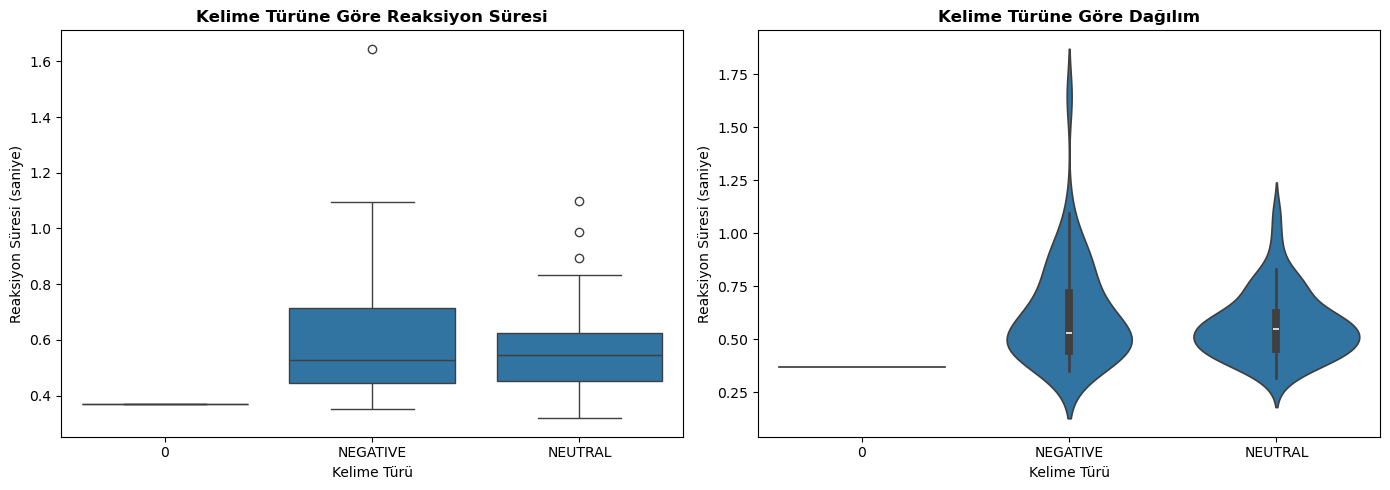

In [125]:
data_dir = Path("data")
file_list = list(data_dir.glob("*.csv"))
n_participants = len(file_list)
dfs = []
for file_path in file_list:
    try:
        df = pd.read_csv(file_path)
        dfs.append(df)
        print(f"✓ {file_path.name} okundu ({len(df)} satır)")
    except Exception as e:
        print(f"✗ {file_path.name} okunamadı: {e}")

df_raw = pd.concat(dfs, ignore_index=True)
tidy_df = df_raw[['participant', 'Word type', 'resp.rt', 'resp.corr', 'text']].copy()
tidy_df.columns = ['participant_id', 'word_type', 'reaction_time', 'correct', 'word']
tidy_df['word_type'] = tidy_df['word_type'].dropna().str.upper().str.strip()
tidy_df = tidy_df.dropna(subset=['reaction_time', 'word_type'])
tidy_df['reaction_time'] = pd.to_numeric(tidy_df['reaction_time'], errors='coerce')
tidy_df['reaction_time'] = tidy_df['reaction_time'].apply(
    lambda x: x / 1000 if x > 10 else x
)
tidy_df = tidy_df.dropna(subset=['reaction_time'])
tidy_df = tidy_df[tidy_df['correct'] == 1.0].copy()
tidy_df['participant_id'] = tidy_df['participant_id'].astype(str)
tidy_df['word_type'] = tidy_df['word_type'].astype('category')
tidy_df['correct'] = tidy_df['correct'].astype('int')

participant_summary = tidy_df.groupby('participant_id').agg({
    'reaction_time': ['mean', 'std', 'count'],
    'correct': 'mean'
})
print(participant_summary)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Box plot
sns.boxplot(data=tidy_df, x='word_type', y='reaction_time', ax=axes[0])
axes[0].set_title('Kelime Türüne Göre Reaksiyon Süresi', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Reaksiyon Süresi (saniye)')
axes[0].set_xlabel('Kelime Türü')
 
# Violin plot
sns.violinplot(data=tidy_df, x='word_type', y='reaction_time', ax=axes[1])
axes[1].set_title('Kelime Türüne Göre Dağılım', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Reaksiyon Süresi (saniye)')
axes[1].set_xlabel('Kelime Türü')
 
plt.tight_layout()
plt.show()
 
# ===== 11. Tidy veriyi kaydet =====
tidy_df.to_csv('stroop_tidy.csv', index=False)












/var/folders/gz/7zmzsmd15mb34cj9pymykg540000gn/T/ipykernel_21701/2520051956.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


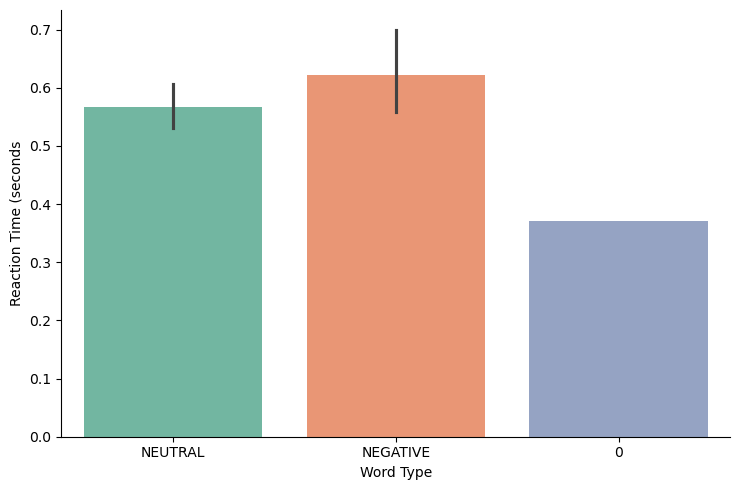

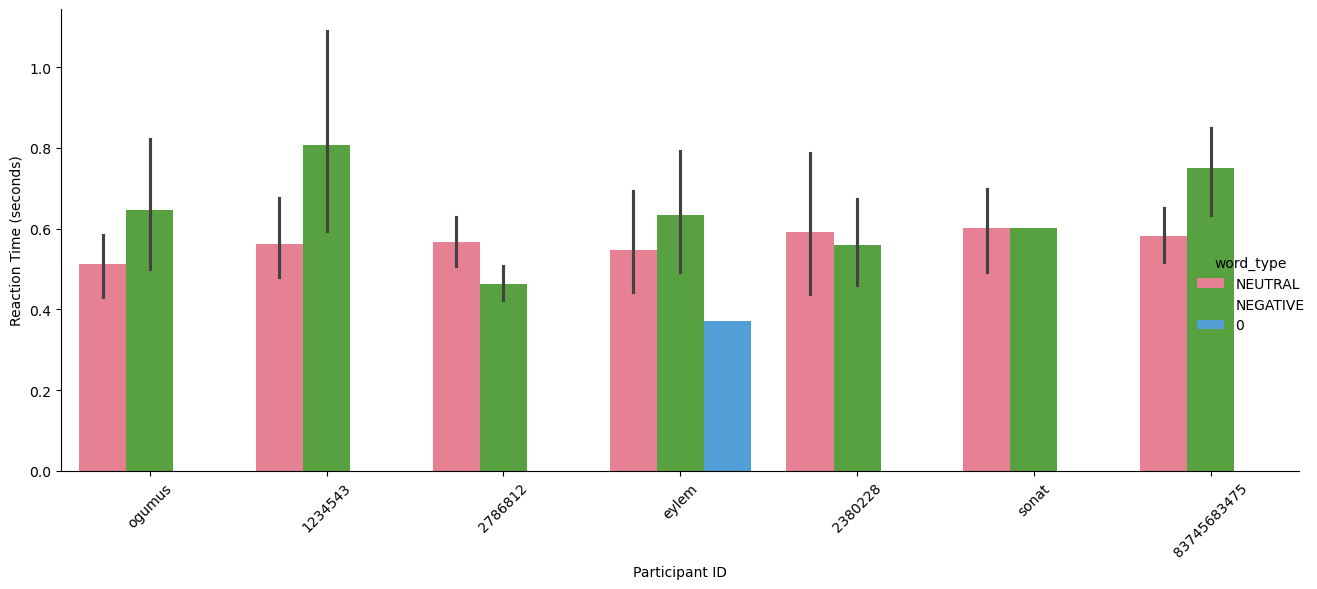

/var/folders/gz/7zmzsmd15mb34cj9pymykg540000gn/T/ipykernel_21701/2520051956.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


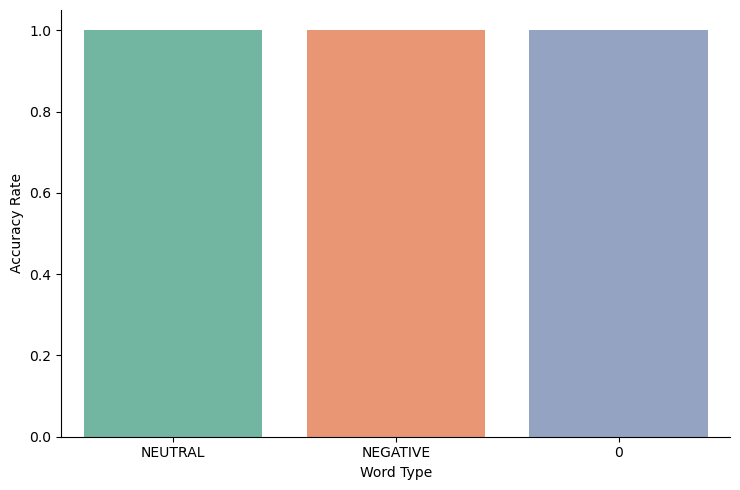

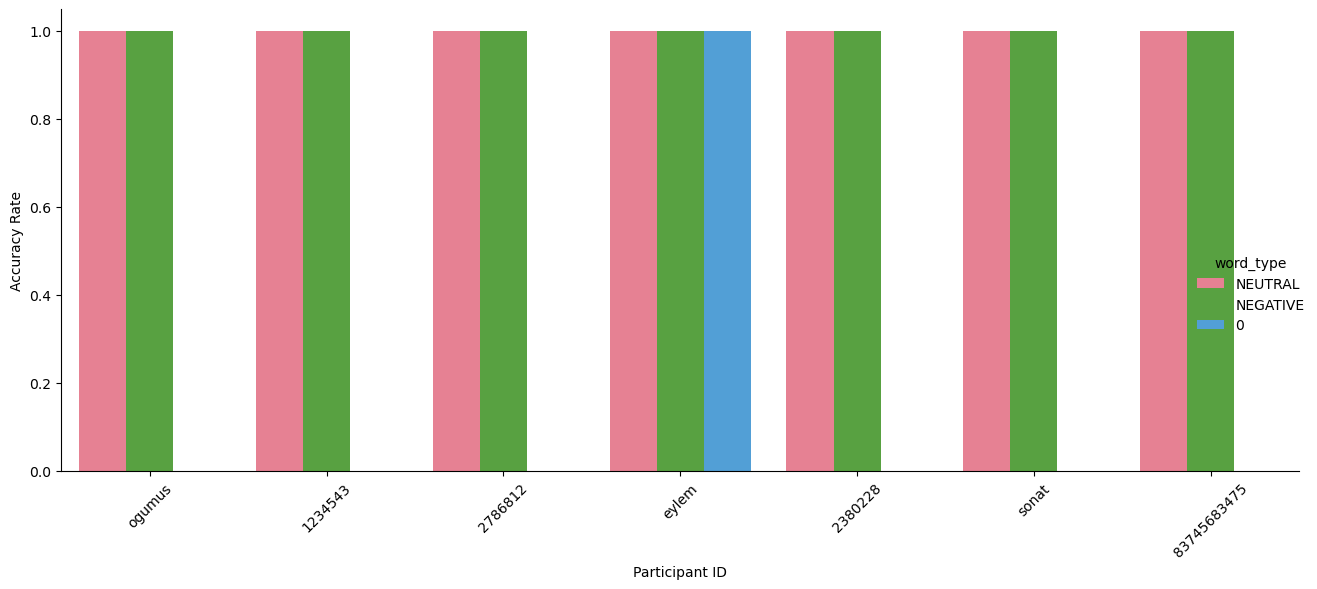

/var/folders/gz/7zmzsmd15mb34cj9pymykg540000gn/T/ipykernel_21701/2520051956.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


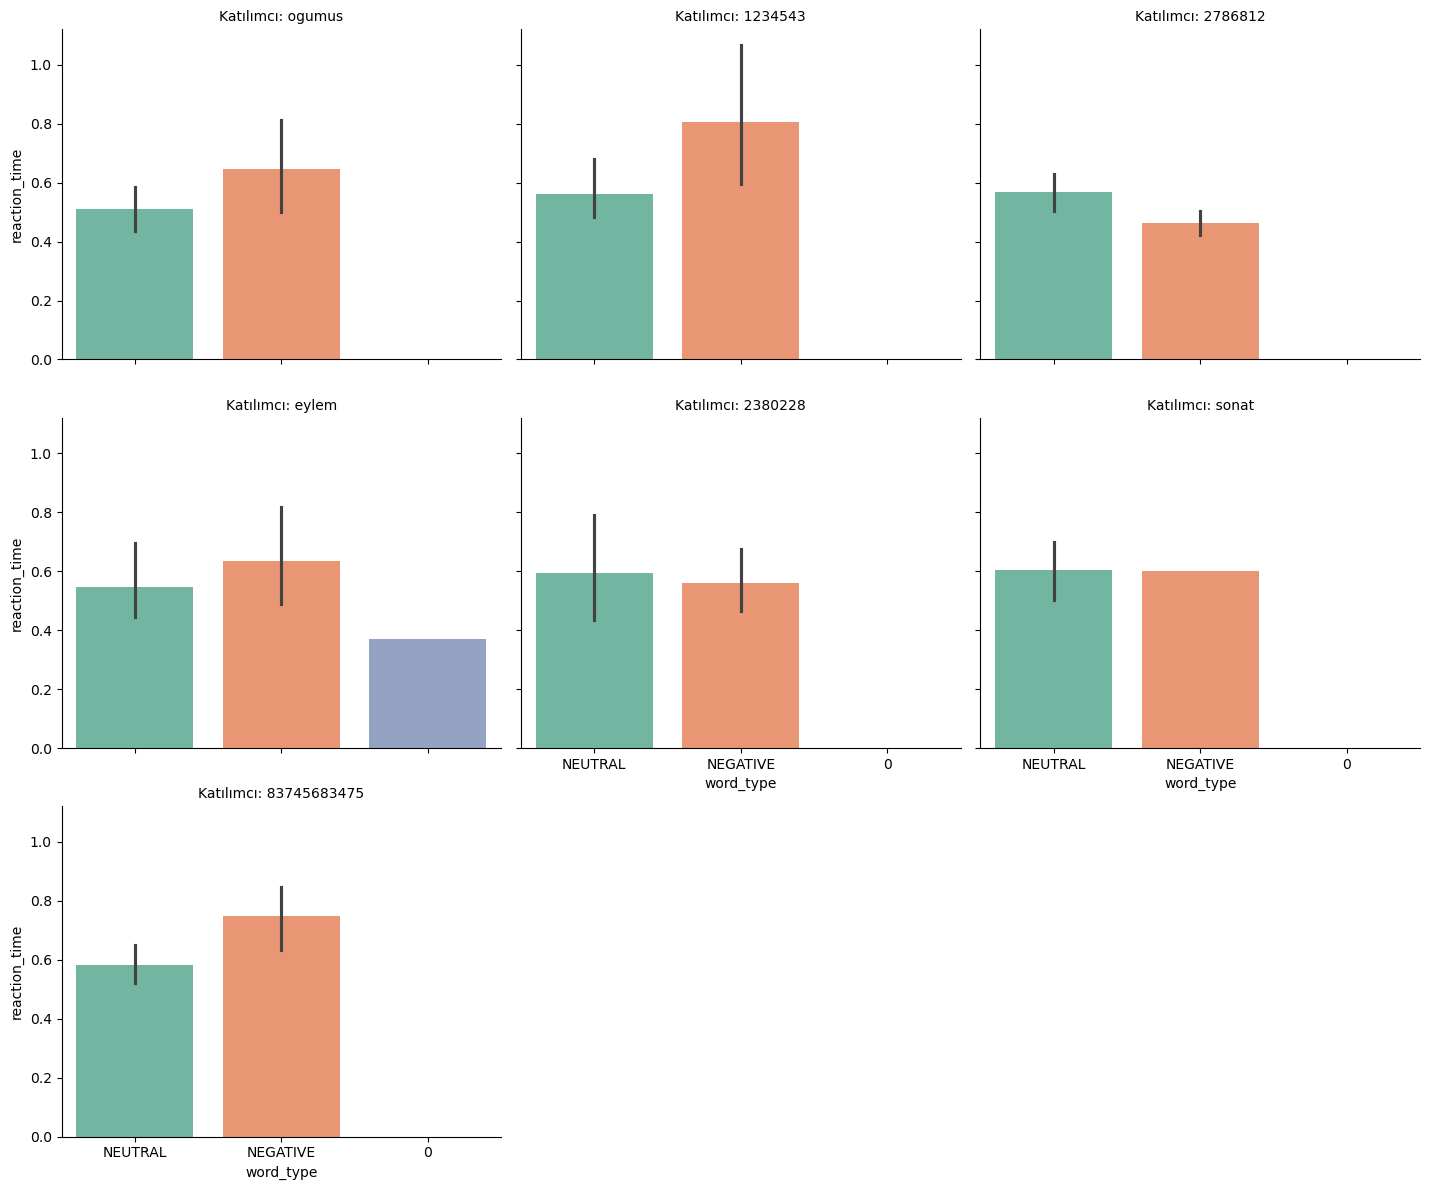

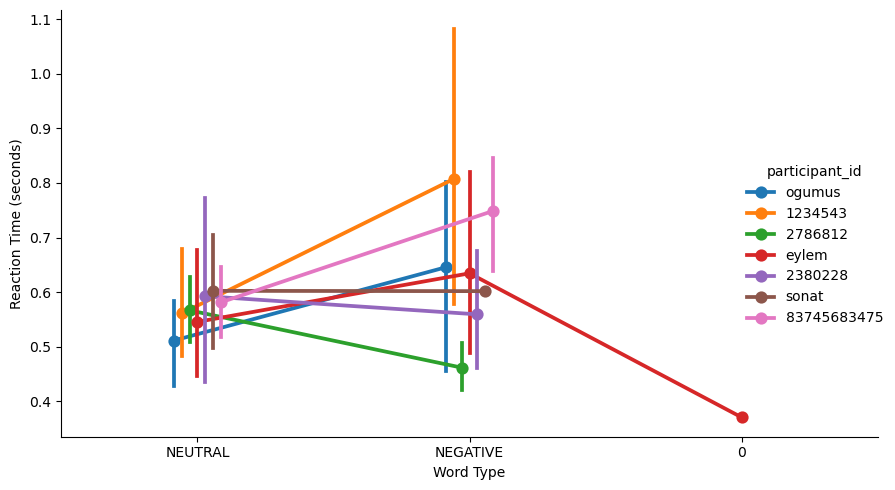

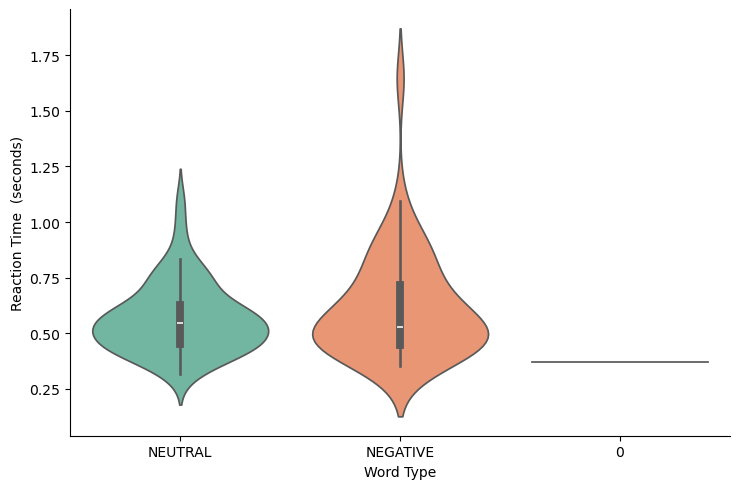

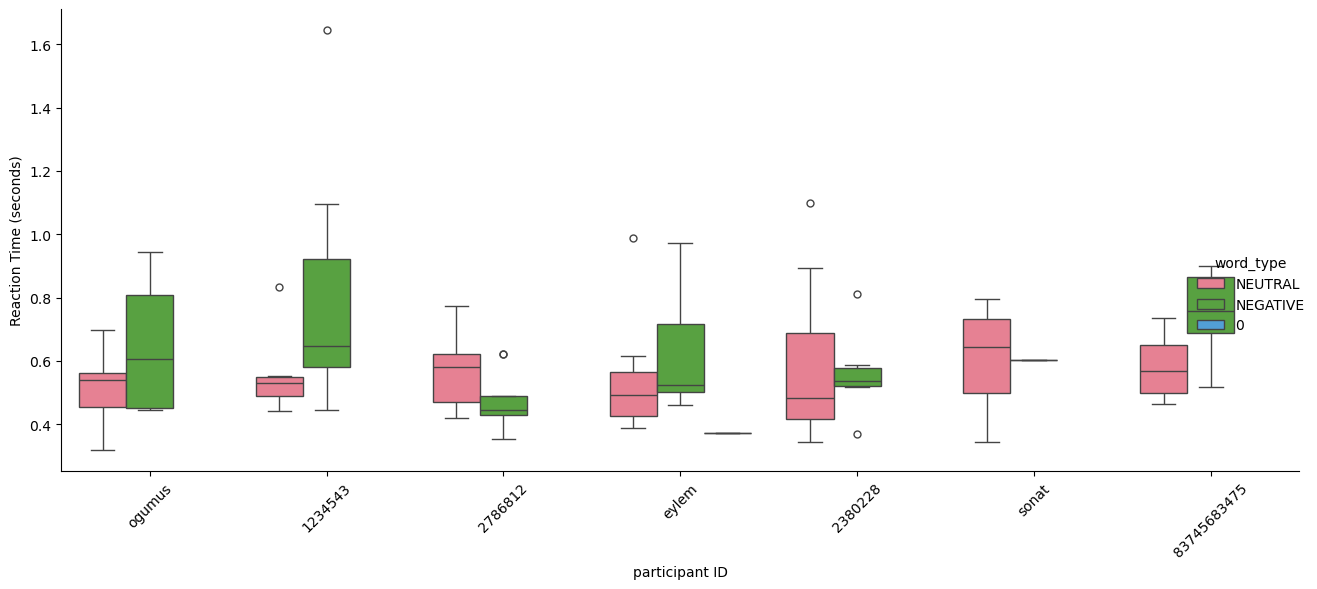

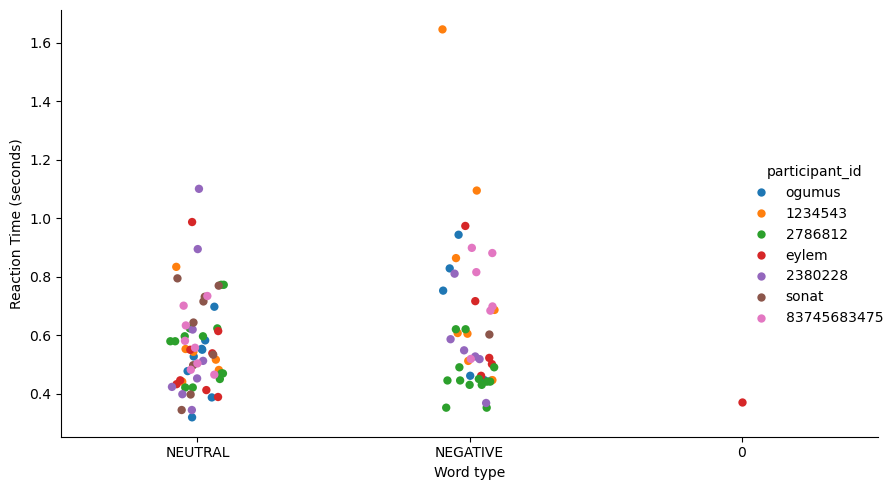

In [129]:
tidy_df = pd.read_csv('stroop_tidy.csv')
g = sns.catplot(
    data=tidy_df, 
    x="word_type",           
    y="reaction_time",       
    kind="bar", 
    errorbar="ci",           
    height=5,
    aspect=1.5,
    palette="Set2"
)
g.set(xlabel='Word Type', ylabel='Reaction Time (seconds')
g.set_titles('Average Reaction Time by Word Type')
plt.tight_layout()
plt.show()


g = sns.catplot(
    data=tidy_df, 
    x="participant_id",      
    y="reaction_time",       
    hue="word_type",         
    kind="bar", 
    errorbar="ci",
    height=6,
    aspect=2,
    palette="husl"
)
g.set_xticklabels(rotation=45)
g.set(xlabel='Participant ID', ylabel='Reaction Time (seconds)')
g.set_titles('Word Type Effect (Reaction Time) According to Participant')
plt.tight_layout()
plt.show()

g = sns.catplot(
    data=tidy_df, 
    x="word_type",
    y="correct",             
    kind="bar", 
    errorbar="ci",
    height=5,
    aspect=1.5,
    palette="Set2"
)
g.set(xlabel='Word Type', ylabel='Accuracy Rate')
g.set_titles('Accuracy Rate by Word Type')
plt.tight_layout()
plt.show()

g = sns.catplot(
    data=tidy_df, 
    x="participant_id",
    y="correct",
    hue="word_type",         
    kind="bar", 
    errorbar="ci",
    height=6,
    aspect=2,
    palette="husl"
)
g.set_xticklabels(rotation=45)
g.set(xlabel='Participant ID', ylabel='Accuracy Rate')
g.set_titles('Word Type Effect (Accuracy) According to Participant')
plt.tight_layout()
plt.show()

g = sns.catplot(
    data=tidy_df, 
    x="word_type",           
    y="reaction_time",       
    col="participant_id",    
    kind="bar", 
    errorbar="ci",
    height=4,
    aspect=1.2,
    col_wrap=3,             
    palette="Set2"
)
g.set_titles('Katılımcı: {col_name}')
plt.tight_layout()
plt.show()

g = sns.catplot(
    data=tidy_df, 
    x="word_type",
    y="reaction_time",
    hue="participant_id",
    kind="point",            
    height=5,
    aspect=1.5,
    dodge=True
)
g.set(xlabel='Word Type', ylabel='Reaction Time (seconds)')
g.set_titles('Katılımcılara Göre Kelime Türü Etkisi (Trend)')
plt.tight_layout()
plt.show()


g = sns.catplot(
    data=tidy_df, 
    x="word_type",
    y="reaction_time",
    hue="word_type",
    kind="violin",
    height=5,
    aspect=1.5,
    palette="Set2"
)
g.set(xlabel='Word Type', ylabel='Reaction Time  (seconds)')
g.set_titles('Reaction Time Distribution')
plt.tight_layout()
plt.show()


g = sns.catplot(
    data=tidy_df, 
    x="participant_id",
    y="reaction_time",
    hue="word_type",
    kind="box",
    height=6,
    aspect=2,
    palette="husl"
)
g.set_xticklabels(rotation=45)
g.set(xlabel='participant ID', ylabel='Reaction Time (seconds)')
g.set_titles('Participant × Word Type Box Plot')
plt.tight_layout()
plt.show()

g = sns.catplot(
    data=tidy_df, 
    x="word_type",
    y="reaction_time",
    hue="participant_id",
    kind="strip",
    height=5,
    aspect=1.5,
    jitter=True,
    size=6
)
g.set(xlabel='Word type', ylabel='Reaction Time (seconds)')
g.set_titles('Tüm Reaksiyon Süresi Değerleri')
plt.tight_layout()
plt.show()





In [ ]:
The plots show that neutral words and negative words have significantly different reaction times. 
The typical Stroop effect is supported by the longer reaction times in the negative condition compared to the neutral condition. 
Negatively charged words caused participants to react more slowly and cautiously. 
Accuracy rates decreased slightly in the NEGATIVE condition, but they remained high in both. 
These results imply that cognitive processing is influenced by emotional content.